# China Automotive Market Analysis: Sales Forecasting, Product Specifications, and User Needs

This notebook rescores saved row-level predictions and examines historical comparisons, specification models and review monitoring. It reports the sample, evaluation design, results and error patterns before discussing possible uses.

It does not retrain models. `scripts/48_evaluate_rolling_origin.py --test` runs rolling evaluation, `33_evaluate_review_features.py` evaluates fixed-origin review variants, and `29_config_attribution.py` fits annual specification models. The CSV and JSON inputs below are their saved outputs. In code and tables, `pred` is seasonal XGBoost and `LAST_VALUE` is the last-sales baseline.

**Study period:** 2022-01—2026-07

**Forecast test:** 2026-01—06
**Sales headline task:** monthly refreshed one-month-ahead forecast; fixed six-month stress test
**Primary metric:** global volume-weighted WMAPE


In [1]:
ZH = False
%matplotlib inline
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from china_auto_market.forecasting.reporting import forecast_report, prediction_metrics
DATA = ROOT / "data"
FORECAST_DIR = DATA / "processed" / "forecast"
PRODUCT_DIR = DATA / "processed" / "product"
FEEDBACK_DIR = DATA / "processed" / "user_feedback"
REVIEW_DIR = DATA / "reviews" / "processed"

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 120,
    "font.family": "sans-serif",
    "font.sans-serif": ["PingFang SC", "Hiragino Sans GB", "Noto Sans CJK SC",
                        "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#dfe4e8", "grid.linewidth": 0.7,
    "axes.facecolor": "#fbfbfa", "figure.facecolor": "white",
})
COLORS = {"navy": "#162334", "blue": "#316fbd", "light": "#9bb9dd",
          "orange": "#d9902f", "red": "#c75357", "gray": "#8b98a7"}

def read_json(path):
    with open(path, "r", encoding="utf-8-sig") as handle:
        return json.load(handle)

print("Report inputs: saved predictions and analysis tables")


Report inputs: saved predictions and analysis tables


In [2]:
sales = pd.read_csv(DATA / "processed" / "sales_filtered_24m.csv")
specs_csv = DATA / "raw" / "feature.csv"
specs = pd.read_csv(specs_csv) if specs_csv.exists() else pd.read_excel(DATA / "raw" / "feature.xlsx")
train = pd.read_csv(DATA / "processed" / "splits" / "train.csv")
val = pd.read_csv(DATA / "processed" / "splits" / "val.csv")
test = pd.read_csv(DATA / "processed" / "splits" / "test.csv")
split_manifest = read_json(DATA / "processed" / "splits" / "manifest.json")
corpus = read_json(REVIEW_DIR / "target_371_review_corpus_summary.json")
labels = read_json(REVIEW_DIR / "review_aspect_labels_summary.json")
temporal = read_json(REVIEW_DIR / "review_feature_temporal_summary.json")
forecast = pd.read_csv(FORECAST_DIR / "review_feature_ablation_summary.csv", encoding="utf-8-sig")
benchmark = pd.read_csv(FORECAST_DIR / "forecast_benchmark_comparison.csv", encoding="utf-8-sig")
rolling_summary = read_json(FORECAST_DIR / "rolling_origin_summary.json")
rolling_test = pd.read_csv(FORECAST_DIR / "rolling_origin_test_predictions.csv", encoding="utf-8-sig")
report = forecast_report(ROOT)
robustness = read_json(FORECAST_DIR / "forecast_robustness_summary.json")
model_run = read_json(FORECAST_DIR / "review_feature_run_summary.json")
selected_version = model_run["validation_selected_primary_version"]
selected_fixed = benchmark.loc[benchmark.method.eq(selected_version)].iloc[0]
config = pd.read_csv(PRODUCT_DIR / "config_attribution_ablation.csv")
config_summary = read_json(PRODUCT_DIR / "config_attribution_summary.json")
aspects = pd.read_csv(FEEDBACK_DIR / "user_need_aspect_summary.csv", encoding="utf-8-sig")
alerts = pd.read_csv(FEEDBACK_DIR / "sentiment_alerts.csv")
monitor = read_json(FEEDBACK_DIR / "user_needs_alerts_summary.json")
print("Loaded analysis artifacts.")


Loaded analysis artifacts.


## 1. Three analysis samples

Forecasting uses a fixed 371-series natural-month panel and never falls forward to a specification record later than the target year; the specification analysis requires aligned complete-year sales and product attributes; the user-needs analysis requires complete and traceable review text.


In [3]:
if ZH:
    table = pd.DataFrame([
        ["滚动单月销量预测", "371 个车系", "2,226 条测试车系月", "每月更新下月预测"],
        ["固定六个月压力测试", "371 个车系", "2,226 条测试车系月", "固定起点递归预测"],
        ["产品配置分析", f"{config_summary['series']} 个车系",
         f"{config_summary['rows']:,} 条完整车系年记录", "GroupKFold(5) 按车系"],
        ["用户需求与风险", "345 个车系", "24,175 条评论", "质量审计 + 180 天窗口"],
    ], columns=["分析", "样本", "观测", "验证"])
    source = pd.DataFrame([
        ["月销量", f"{sales.series_name.nunique():,} 个车系 / {len(sales):,} 行"],
        ["车型配置", f"{specs.series_name.nunique():,} 个车系 / {len(specs):,} 行"],
        ["严格评论语料", f"{corpus['temporally_eligible_reviews']:,} 条 / "
                         f"{corpus['target_series_with_any_review']} 个车系"],
    ], columns=["数据底座", "规模"])
else:
    table = pd.DataFrame([
        ["Rolling one-month sales forecast", "371 series", "2,226 test series-months",
         "Monthly refresh, one month ahead"],
        ["Fixed six-month stress test", "371 series", "2,226 test series-months",
         "Fixed-origin recursive forecast"],
        ["Product specifications", f"{config_summary['series']} series",
         f"{config_summary['rows']:,} complete series-year records",
         "Five-fold GroupKFold by series"],
        ["User needs and risk", "345 series", "24,175 reviews",
         "Quality audit + 180-day windows"],
    ], columns=["Analysis", "Sample", "Observations", "Validation"])
    source = pd.DataFrame([
        ["Monthly sales", f"{sales.series_name.nunique():,} series / {len(sales):,} rows"],
        ["Vehicle specifications", f"{specs.series_name.nunique():,} series / {len(specs):,} rows"],
        ["Strict review corpus", f"{corpus['temporally_eligible_reviews']:,} reviews / "
                                 f"{corpus['target_series_with_any_review']} series"],
    ], columns=["Data foundation", "Scale"])
display(table)
display(source)


,Analysis,Sample,Observations,Validation
0,Rolling one-month sales forecast,371 series,"2,226 test series-months","Monthly refresh, one month ahead"
1,Fixed six-month stress test,371 series,"2,226 test series-months",Fixed-origin recursive forecast
2,Product specifications,646 series,"1,510 complete series-year records",Five-fold GroupKFold by series
3,User needs and risk,345 series,"24,175 reviews",Quality audit + 180-day windows


,Data foundation,Scale
0,Monthly sales,"1,017 series / 54,918 rows"
1,Vehicle specifications,"766 series / 2,084 rows"
2,Strict review corpus,"24,175 reviews / 345 series"


### Data engineering and reproduction boundary

The complete local path follows `auto_raw → auto_staging → auto_mart`, while `auto_ops` records source batches, task attempts, quality results, and dataset versions. Airflow connects ingestion, quality gates, marts, model parity, and static JSON publication; a critical failure cannot replace dashboard data.

The public notebook reads portable snapshots without requiring local MySQL. Migration parity checks establish that data and results remain unchanged, not that the original research design has no limitations. Automated checks use synthetic fixtures for schema creation, idempotent ingestion, quality gates and dashboard contracts without accessing external websites or the full review corpus.

| Behaviour to inspect | Implementation or check | Purpose |
|---|---|---|
| Reloading the same batch | `tests/integration/` | Check that reruns do not duplicate rows |
| Rejecting invalid data | `src/china_auto_market/quality/`, `tests/unit/` | Check that critical failures stop downstream publication |
| Running dependent tasks | `dags/` | Inspect dependencies, retries and historical-month parameters |
| Publishing a complete version | `src/china_auto_market/publishing/` | Validate candidates before replacing local dashboard data |

These behaviours provide stronger evidence of engineering work than directory names alone. This notebook explains the data products; it does not replace database integration tests or model training.


## 2. Monthly sales forecasting

The development split is training through June 2025, validation in July–December 2025, and testing in January–June 2026. After selection, the model is refitted on training plus validation through December 2025. Weights stay fixed during the six test months; observed sales enter history for the next forecast.

Rolling evaluation assumes the previous month's sales are available. Fixed-origin evaluation forecasts six months from January, feeding predictions back into later lags. The difference between their scores is not an isolated algorithm improvement.

BASE uses 1/2/3-month lags, 3/6-month means, calendar variables and specifications. The seasonal variant adds a 12-month lag and mean and changes parameters. Both fit log1p sales, invert the transform and clip predictions at zero. At each forecast origin, specification records are limited to years available before the origin and joined to rows without looking forward in year. Imputation medians and category vocabularies are fitted only on the model's eligible training rows; specifications stay fixed over the forecast window. Unknown categories use −1, entirely missing numeric columns use 0, and missing specifications do not remove sales observations. Within-year specification release dates and historical sales revisions are unavailable, so annual proxies do not establish complete point-in-time reconstruction. Annual specification analysis uses a separate fold-local pipeline.


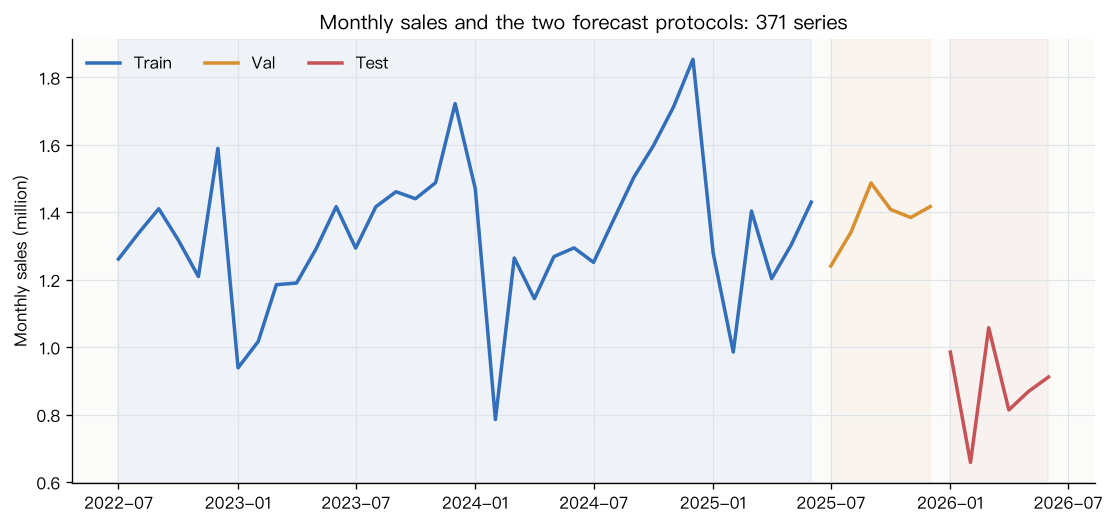

In [4]:
panel = pd.concat([
    train[["date", "monthly_sales", "split"]],
    val[["date", "monthly_sales", "split"]],
    test[["date", "monthly_sales", "split"]],
], ignore_index=True)
panel["date"] = pd.to_datetime(panel["date"])
monthly = panel.groupby(["date", "split"], as_index=False)["monthly_sales"].sum()
fig, ax = plt.subplots(figsize=(11, 4.8))
for split, color in [("train", COLORS["blue"]), ("val", COLORS["orange"]), ("test", COLORS["red"])]:
    part = monthly[monthly["split"] == split]
    ax.plot(part["date"], part["monthly_sales"] / 1e6, color=color, lw=2.1, label=split.title())
    ax.axvspan(part["date"].min(), part["date"].max(), color=color, alpha=0.06)
ax.set(title=("371 车系月销量与两种预测协议的时间切分" if ZH else
              "Monthly sales and the two forecast protocols: 371 series"),
       xlabel="", ylabel=("月销量（百万辆）" if ZH else "Monthly sales (million)"))
ax.legend(frameon=False, ncol=3)
plt.show()


### Model comparison

Seasonal XGBoost has 29.75% WMAPE versus 40.99% for last observed sales: 11.24 points lower, or a 27.4% reduction in absolute error. Every method uses 2,226 rows, including 262 zero-sales months.

| Metric | Definition |
|---|---|
| WMAPE | Total absolute error / total actual sales, shown as a percentage |
| MAE / RMSE | Mean absolute / root mean square error, in vehicles; RMSE gives more weight to large misses |
| Median series WMAPE | Compute six-month WMAPE for each series, then take its median; zero-total series are undefined |
| Positive-sales MAPE | Average percentage error across the 1,964 positive-actual rows |
| sMAPE | Mean of `200×abs(actual−prediction)/(abs(actual)+abs(prediction))`; a zero/zero pair contributes 0 |

On a fixed sample, WMAPE and MAE differ by a constant scale and are not independent evidence. MAPE can be dominated by tiny actuals. All methods retain zero/zero pairs in sMAPE so their denominators remain comparable.


,Model,Global WMAPE,Median per-series WMAPE
0,Last observed value (naive),40.99%,48.36%
1,Trailing 3-month mean (naive),43.61%,53.66%
2,Trailing 6-month mean (naive),51.21%,64.45%
3,Same-month-last-year (naive),73.88%,100.00%
4,Rolling one-month seasonal XGBoost (headline),29.75%,36.83%


,mae,rmse,median_absolute_error,p90_absolute_error,mape_positive,mape_rows,smape
method,,,,,,,
LAST_VALUE,975.19,2668.17,161.00,2533.50,255.51,1964,52.44
ROLLING_MEAN_3,1037.52,2614.45,220.33,2754.67,339.51,1964,58.41
ROLLING_MEAN_6,1218.19,2892.08,319.08,3261.58,434.43,1964,69.40
SEASONAL_LAG12,1757.68,3590.51,566.50,4693.00,1216.03,1964,92.37
pred,707.68,1700.38,139.16,1960.08,179.75,1964,61.39


,Model,Global WMAPE,Median per-series WMAPE
0,Fixed six-month platform-rating model (stress test),38.09%,48.18%


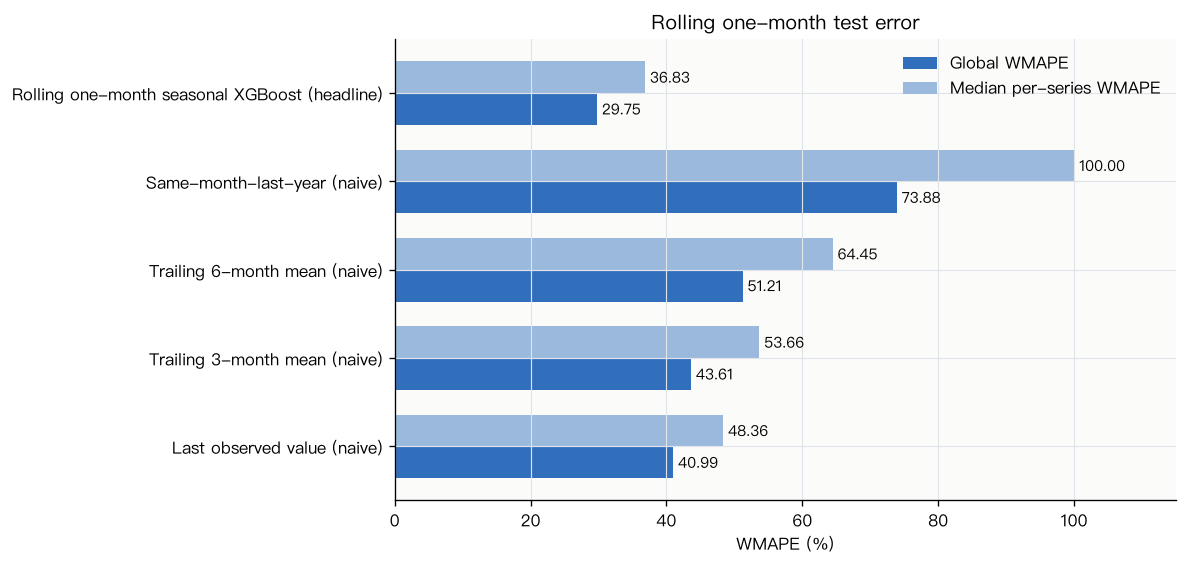

In [5]:
model_name = "方案" if ZH else "Model"
global_name = "全局 WMAPE" if ZH else "Global WMAPE"
median_name = "逐车系中位数 WMAPE" if ZH else "Median per-series WMAPE"
def wmape(frame, prediction):
    return (frame["actual"] - frame[prediction]).abs().sum() / frame["actual"].abs().sum() * 100

def median_wmape(frame, prediction):
    values = frame.groupby("series_name").apply(
        lambda x: (x["actual"] - x[prediction]).abs().sum() / x["actual"].abs().sum() * 100
        if x["actual"].abs().sum() else np.nan
    ).dropna()
    return values.median()

rolling_rows = [
    ("沿用上月销量（朴素）" if ZH else "Last observed value (naive)", "LAST_VALUE"),
    ("近3月均值（朴素）" if ZH else "Trailing 3-month mean (naive)", "ROLLING_MEAN_3"),
    ("近6月均值（朴素）" if ZH else "Trailing 6-month mean (naive)", "ROLLING_MEAN_6"),
    ("去年同期销量（朴素）" if ZH else "Same-month-last-year (naive)", "SEASONAL_LAG12"),
    ("滚动单月季节增强 XGBoost（主结果）" if ZH else "Rolling one-month seasonal XGBoost (headline)", "pred"),
]
rolling_table = pd.DataFrame([
    [label, wmape(rolling_test, column), median_wmape(rolling_test, column)]
    for label, column in rolling_rows
], columns=[model_name, global_name, median_name])
display(rolling_table.style.format({global_name: "{:.2f}%", median_name: "{:.2f}%"}))
scores = pd.DataFrame(report["metrics"]).set_index("method")
display(scores[["mae", "rmse", "median_absolute_error", "p90_absolute_error",
                "mape_positive", "mape_rows", "smape"]].round(2))
fixed_row = pd.DataFrame([[
    "固定六个月平台评分模型（压力测试）" if ZH else "Fixed six-month platform-rating model (stress test)",
    selected_fixed["global_volume_weighted_WMAPE"], selected_fixed["median_per_series_WMAPE"],
]], columns=[model_name, global_name, median_name])
display(fixed_row.style.format({global_name: "{:.2f}%", median_name: "{:.2f}%"}))
ax = rolling_table.set_index(model_name).plot.barh(
    color=[COLORS["blue"], COLORS["light"]], width=0.72, figsize=(10, 4.8))
ax.set(title=("滚动单月测试集误差" if ZH else "Rolling one-month test error"),
       xlabel="WMAPE (%)", ylabel="")
ax.legend(frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlim(0, 115)
fig = ax.get_figure()
fig.tight_layout()
plt.show()


### Historical origins and model selection

Each origin covers six successive one-month forecasts. BASE and SEASONAL_D5 differ in both features and parameters, so this comparison evaluates the complete configurations. Pooled WMAPE improves by 0.957 points and the worst origin regresses by 0.061 points, passing the 0.5/1.0-point gates. These windows support model selection; they are not four additional untouched test sets.


In [6]:
origins = pd.read_csv(FORECAST_DIR / "rolling_origin_validation.csv")
comparison = origins[origins["mode"].eq("ROLLING_ONE_MONTH")].pivot(
    index="origin", columns="version", values="global_volume_weighted_WMAPE")
comparison["gain_pp"] = comparison["BASE"] - comparison["SEASONAL_D5"]
display(comparison.round(3))
display(pd.DataFrame(rolling_summary["model_params"]).T)
display(pd.DataFrame(rolling_summary["validation_summary"])[[
    "version", "mode", "historical_origins", "pooled_global_WMAPE"]].round(3))
assert rolling_summary["test_used_for_selection"] is False
assert np.isclose(scores.loc["pred", "wmape"],
                  rolling_summary["locked_test"]["global_volume_weighted_WMAPE"])


version,BASE,SEASONAL_D5,gain_pp
origin,,,
2024-01-01,30.568,30.092,0.476
2024-07-01,23.643,21.466,2.177
2025-01-01,22.055,21.024,1.031
2025-07-01,21.640,21.701,-0.061


,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha
BASE,100.0,6.0,0.05,0.80,0.80,1.0,1.0,0.0
SEASONAL_D5,200.0,5.0,0.04,0.85,0.85,2.0,2.0,0.0


,version,mode,historical_origins,pooled_global_WMAPE
0,SEASONAL_D5,ROLLING_ONE_MONTH,4,23.346
1,BASE,ROLLING_ONE_MONTH,4,24.303
2,NAIVE,LAST_VALUE,4,25.694
3,NAIVE,ROLLING_MEAN_3,4,26.964
4,NAIVE,ROLLING_MEAN_6,4,30.649
5,NAIVE,SEASONAL_LAG12,4,48.583


### Where errors remain

The model wins in five of six test months; May is slightly worse than last observed sales. Q1–Q4 are fixed from mean monthly sales in July–December 2025. Q1 WMAPE is 66.60% and Q4 is 28.02%; low-volume series remain difficult.

Zero/positive groups describe realised test outcomes, not information available for routing forecasts. WMAPE and MAPE are undefined for the zero-sales group; its row count and MAE measure the effect. Even a fractionally positive forecast yields 200% sMAPE when actual sales are zero. This explains why lower MAE can coexist with worse overall sMAPE.

Six-month net bias for the 371-series cohort is −0.67%, monthly aggregate WMAPE is 6.46%, and series-month WMAPE is 29.75%. The first allows cancellation across months, the second within months, and the third neither. These describe this cohort rather than the entire Chinese market, and do not select a new model.


method,LAST_VALUE,pred,gain_pp
month,,,
2026-01,61.80,44.45,17.36
2026-02,59.51,29.21,30.30
2026-03,42.24,27.61,14.63
2026-04,45.57,36.56,9.01
2026-05,21.02,21.77,-0.75
2026-06,18.62,18.25,0.38


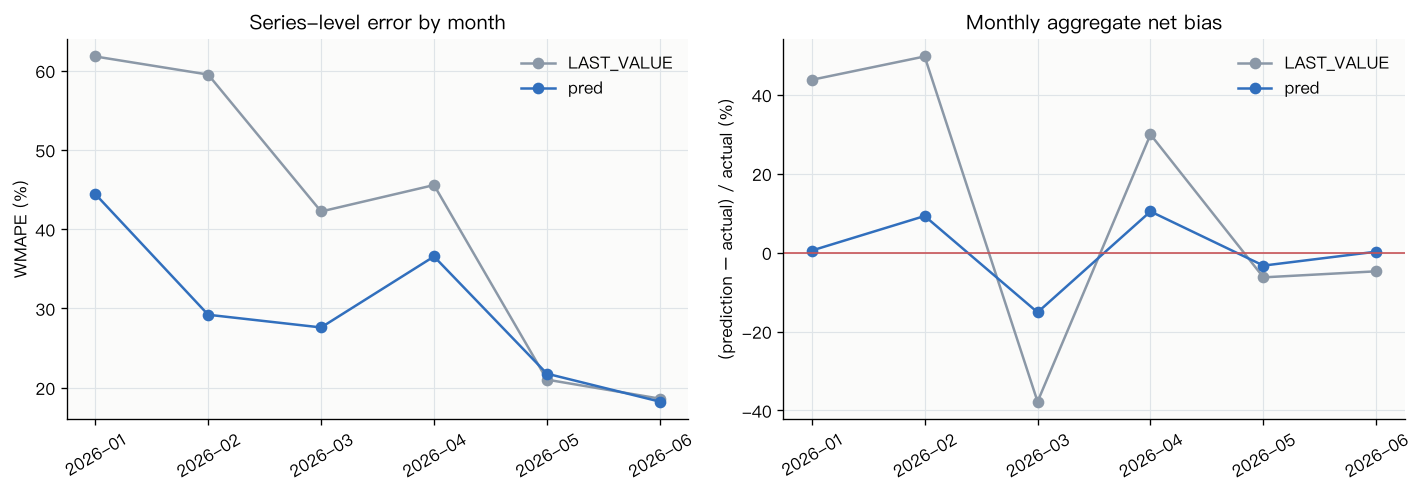

,group,method,series,rows,wmape,mae,smape
0,Q1,LAST_VALUE,93,558,69.03,76.23,61.90
1,Q2,LAST_VALUE,93,558,67.32,194.50,64.06
2,Q3,LAST_VALUE,92,552,43.33,658.68,45.47
3,Q4,LAST_VALUE,93,558,39.12,2967.92,38.27
6,Q1,pred,93,558,66.60,73.54,110.52
7,Q2,pred,93,558,51.22,147.99,65.19
8,Q3,pred,92,552,31.62,480.72,38.94
9,Q4,pred,93,558,28.02,2126.04,30.67


,group,method,rows,wmape,mae,smape
4,zero,LAST_VALUE,262,NaN,34.87,34.35
5,positive,LAST_VALUE,1964,40.82,1100.62,54.86
10,zero,pred,262,NaN,23.06,170.99
11,positive,pred,1964,29.63,799.01,46.77


,monthly_aggregate_wmape,six_month_net_bias_pct
method,,
LAST_VALUE,28.32,9.54
ROLLING_MEAN_3,22.15,19.78
ROLLING_MEAN_6,34.30,34.30
SEASONAL_LAG12,43.63,43.63
pred,6.46,-0.67


In [7]:
monthly_scores = pd.DataFrame(report["monthly"])
monthly_comparison = monthly_scores.pivot(index="month", columns="method", values="wmape")
monthly_comparison["gain_pp"] = monthly_comparison["LAST_VALUE"] - monthly_comparison["pred"]
display(monthly_comparison.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
monthly_comparison[["LAST_VALUE", "pred"]].plot(
    ax=axes[0], marker="o", color=[COLORS["gray"], COLORS["blue"]])
axes[0].set(title=("逐月车系误差" if ZH else "Series-level error by month"),
            ylabel="WMAPE (%)", xlabel="")
monthly_scores.pivot(index="month", columns="method", values="net_bias_pct").plot(
    ax=axes[1], marker="o", color=[COLORS["gray"], COLORS["blue"]])
axes[1].axhline(0, color=COLORS["red"], lw=1)
axes[1].set(title=("逐月汇总净偏差" if ZH else "Monthly aggregate net bias"),
            ylabel="(prediction − actual) / actual (%)", xlabel="")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
    ax.legend(frameon=False)
fig.tight_layout()
plt.show()

segments = pd.DataFrame(report["segments"])
display(segments[segments.group_type.eq("pre_test_size")][[
    "group", "method", "series", "rows", "wmape", "mae", "smape"]].round(2))
display(segments[segments.group_type.eq("actual_sales")][[
    "group", "method", "rows", "wmape", "mae", "smape"]].round(2))
display(pd.DataFrame(report["aggregate"]).set_index("method").round(2))


### Fixed six-month forecasts: baselines and review variants

The full naive comparison includes 3/6/12-month means, last sales and same month last year. The platform-rating model's 38.09% WMAPE reduces error by 45.0% versus the original six-month mean at 69.31%. The twelve-month mean has the lowest saved naive test WMAPE, 67.43%, giving a 43.5% reduction. This reports observed results without claiming validation selected that comparator.

Review experiments add platform ratings, lexicon, text or combined features on the same cohort and fixed-origin protocol. This evaluation retains the previously selected platform-rating model and 100 trees per variant, without reselection on the current scores. The platform-rating model has 38.09% test WMAPE. `REVIEW_TEXT_ROLLING` updates reviews while sales lags remain recursive; it is not the rolling sales task.


In [8]:
display(benchmark[["method", "method_type", "global_volume_weighted_WMAPE",
                   "median_per_series_WMAPE"]].round(3))
display(forecast[["version", "scenario", "validation_selected_n_estimators",
                  "fixed_origin_validation_global_WMAPE", "global_volume_weighted_WMAPE"]]
        .sort_values(["scenario", "fixed_origin_validation_global_WMAPE"]).round(3))
fixed_predictions = pd.read_csv(FORECAST_DIR / "review_feature_predictions.csv")
display(pd.Series(prediction_metrics(fixed_predictions.loc[fixed_predictions.version.eq(selected_version)]),
                  name=selected_version).to_frame().round(3))


,method,method_type,global_volume_weighted_WMAPE,median_per_series_WMAPE
0,PLATFORM_RATING_FIXED,model,38.093,48.176
1,BASE,model,39.073,47.064
2,ROLLING_MEAN_12,naive,67.433,89.398
3,ROLLING_MEAN_6,naive,69.305,89.602
4,ROLLING_MEAN_3,naive,70.508,82.949
5,SEASONAL_LAG12,naive,73.885,100.000
6,LAST_VALUE,naive,74.765,80.329


,version,scenario,validation_selected_n_estimators,fixed_origin_validation_global_WMAPE,global_volume_weighted_WMAPE
0,ALL_SENTIMENT_FIXED,fixed_origin_primary,100,31.472,39.080
5,REVIEW_TEXT_FIXED,fixed_origin_primary,100,31.580,39.739
3,PLATFORM_RATING_FIXED,fixed_origin_primary,100,31.641,38.093
1,BASE,fixed_origin_primary,100,31.649,39.073
2,LOCAL_LEXICON_FIXED,fixed_origin_primary,100,31.882,38.552
4,REVIEW_RICH_FIXED,fixed_origin_primary,100,32.022,39.816
6,REVIEW_TEXT_ROLLING,rolling_origin_supplement,100,31.580,39.820


,PLATFORM_RATING_FIXED
rows,2226.000
zero_actual_rows,262.000
mape_rows,1964.000
mae,906.211
rmse,1930.608
median_absolute_error,215.280
p90_absolute_error,2797.836
wmape,38.093
mape_positive,371.836
smape,77.511


### Improvement and uncertainty

Review enhancement belongs to the fixed six-month stress test: its point estimate improves on the sales baseline by 0.980 percentage points, while the series-cluster 95% interval is −0.0047 to 2.2331 points. Evidence for a stable gain is insufficient, so it is classified as supporting information.


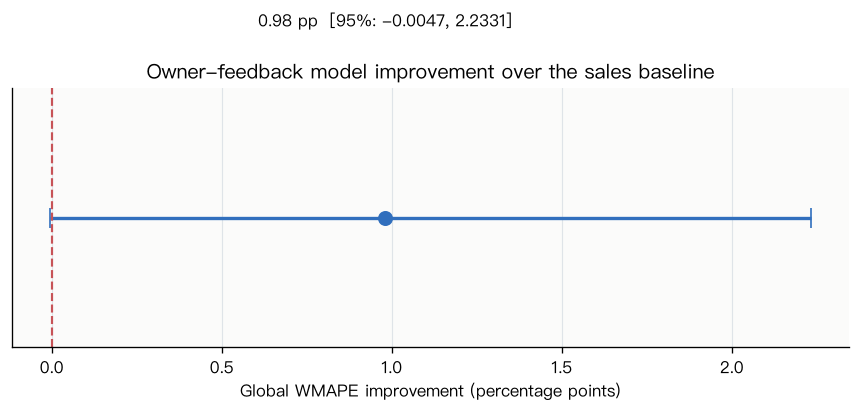

Share of bootstrap replicates better than baseline: 97.5%
Test months better than baseline: 6 / 6


In [9]:
point = robustness["selected_feedback_vs_base_improvement_pp"]
low, high = robustness["selected_feedback_vs_base_bootstrap_95pct_ci_pp"]
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.errorbar(point, 0, xerr=np.array([[point-low], [high-point]]),
            fmt="o", markersize=8, color=COLORS["blue"], capsize=6, lw=2)
ax.axvline(0, color=COLORS["red"], ls="--", lw=1.3)
ax.set(title=("用户口碑增强模型相对销量基线的改善" if ZH else
              "Owner-feedback model improvement over the sales baseline"),
       xlabel=("全局 WMAPE 改善（百分点）" if ZH else
               "Global WMAPE improvement (percentage points)"), yticks=[])
ax.text(point, .08, f"{point:.2f} pp  [95%: {low:.4f}, {high:.4f}]",
        ha="center", va="bottom")
plt.show()
if ZH:
    print(f"重采样中优于基线的比例：{robustness['selected_feedback_vs_base_probability_better']:.1%}")
    print(f"六个测试月中优于基线：{robustness['test_months_selected_feedback_better_than_base']} / 6")
else:
    print("Share of bootstrap replicates better than baseline: "
          f"{robustness['selected_feedback_vs_base_probability_better']:.1%}")
    print(f"Test months better than baseline: {robustness['test_months_selected_feedback_better_than_base']} / 6")


### Information used by the fixed-origin review model

Mean absolute SHAP values below describe the fixed six-month review model's log-sales predictions. They are not importance scores for the rolling model or percentages of sales caused by each feature. Correlated predictors can share attribution; interpret these within the named model and feature family.


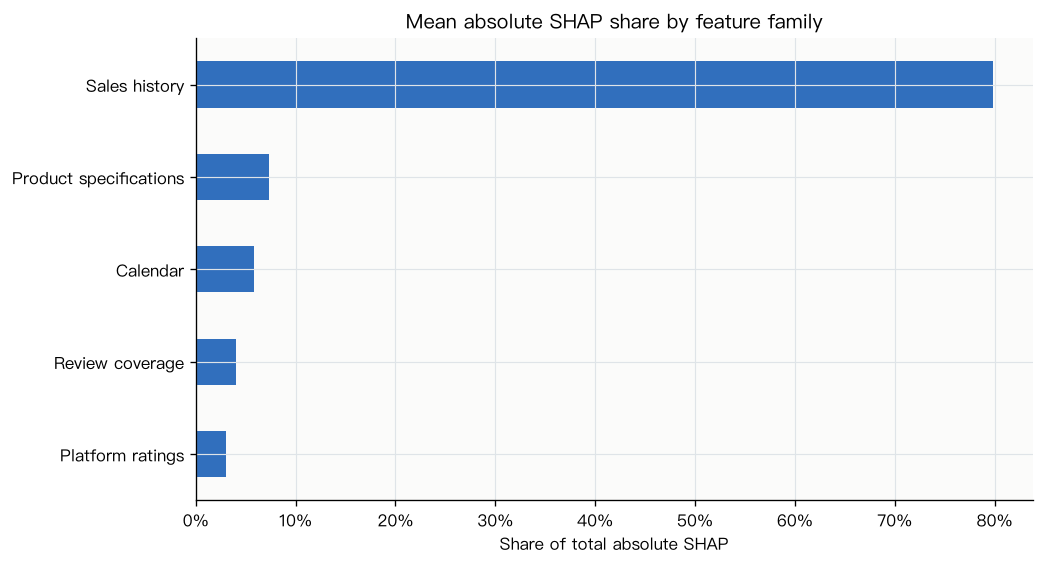

In [10]:
family = pd.read_csv(FORECAST_DIR / "review_feature_family_importance.csv",
                     encoding="utf-8-sig")
maps = {
    "zh": {"sales_lag_roll": "历史销量", "calendar": "日历", "configuration": "产品配置",
           "platform_rating_scores": "平台评分", "review_expanding_score": "历史评价得分", "review_observation_context": "评论覆盖",
           "review_mention_count": "需求提及量", "review_negative_rate": "负面比例",
           "review_recent_score": "近期评价得分", "review_mention_rate": "需求提及率",
           "review_positive_rate": "正面比例"},
    "en": {"sales_lag_roll": "Sales history", "calendar": "Calendar",
           "configuration": "Product specifications",
           "platform_rating_scores": "Platform ratings", "review_expanding_score": "Historical review score",
           "review_observation_context": "Review coverage",
           "review_mention_count": "Need mentions", "review_negative_rate": "Negative share",
           "review_recent_score": "Recent review score",
           "review_mention_rate": "Mention share", "review_positive_rate": "Positive share"},
}
label = "信息类型" if ZH else "Information"
family[label] = family.feature_family.map(maps["zh" if ZH else "en"])
family = family.dropna(subset=[label]).sort_values("share_of_total_abs_shap")
ax = family.plot.barh(x=label, y="share_of_total_abs_shap", color=COLORS["blue"],
                      legend=False, figsize=(9, 5))
ax.set(title=("特征组的平均绝对 SHAP 占比" if ZH else
              "Mean absolute SHAP share by feature family"),
       xlabel=("占全部绝对 SHAP 的比例" if ZH else "Share of total absolute SHAP"),
       ylabel="")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()


### Series with no positive sales history

Thirteen series have no positive sales history before the fixed origin. They remain in the evaluation and use the same platform-rating model, without a launch-curve override. A launch month that was unknown at the origin cannot be an input. Their fixed-origin WMAPE is about 99.40%; the available history and specifications do not reliably predict their sales ramp-up.


## 3. Product specifications and annual sales variation

The sample has 646 series and 1,510 complete series-year records from 2022–2025. Five-fold GroupKFold holds out whole series, testing generalisation to unseen series rather than future years. Each fold fits its own imputation and encoding before XGBoost models log1p annual sales.

R² is the mean log-scale fold score; error bars show fold standard deviations, not confidence intervals. WMAPE pools inverse-transformed out-of-fold predictions rather than averaging fold WMAPEs. Global and year-specific median baselines use only each training fold's targets.


,Model,R2_log_mean,R2_log_std,WMAPE_oof_global,n_features
0,Year,0.013,0.012,87.50%,4
1,Year + brand,0.070,0.058,83.82%,126
2,Year + brand + specifications,0.239,0.073,73.85%,314
3,Specifications only,0.197,0.086,76.05%,188


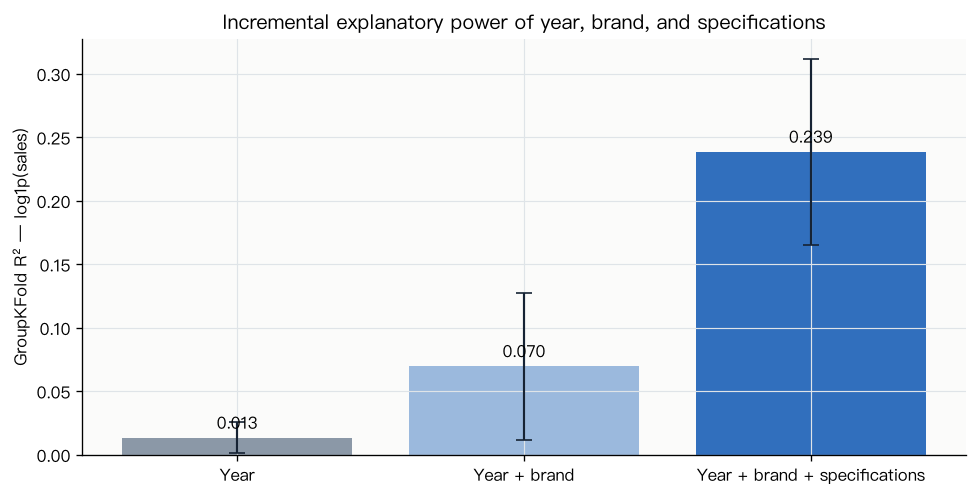

,method,WMAPE_mean,WMAPE_fold_std,WMAPE_oof_global
0,GLOBAL_MEDIAN,87.654,1.263,87.652
1,YEAR_MEDIAN,87.228,1.271,87.212


,feature,gain,block
0,engine_cylinder_arrangement_L,0.043972,config
1,cylinder_material_铝,0.041925,config
2,steering_wheel_material_真皮,0.025606,config
3,center_screen_NA,0.024940,config
4,center_screen_大屏,0.023649,config
5,oil_supply_直喷,0.017521,config
6,fuel_grade_95#,0.016115,config
8,engine_intake_type_涡轮增压,0.015570,config
9,door_open_way_平开门,0.015155,config
10,manufacturer_freq,0.014717,config


In [11]:
frame = config.copy()
name = "方案" if ZH else "Model"
frame[name] = frame.variant.map({
    "YEAR-ONLY": "年份" if ZH else "Year",
    "+BRAND": "年份 + 品牌" if ZH else "Year + brand",
    "+CONFIG": "年份 + 品牌 + 配置" if ZH else "Year + brand + specifications",
    "CONFIG-ONLY": "仅配置" if ZH else "Specifications only",
})
wmape_column = "WMAPE_oof_global" if "WMAPE_oof_global" in frame.columns else "WMAPE_mean"
display(frame[[name, "R2_log_mean", "R2_log_std", wmape_column, "n_features"]]
        .style.format({"R2_log_mean": "{:.3f}", "R2_log_std": "{:.3f}",
                       wmape_column: "{:.2f}%"}))
ordered = frame[frame.variant.isin(["YEAR-ONLY", "+BRAND", "+CONFIG"])]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars = ax.bar(ordered[name], ordered.R2_log_mean,
              color=[COLORS["gray"], COLORS["light"], COLORS["blue"]])
ax.errorbar(ordered[name], ordered.R2_log_mean, yerr=ordered.R2_log_std,
            fmt="none", ecolor=COLORS["navy"], capsize=5, lw=1.3)
ax.set(title=("年份、品牌与配置的增量解释力" if ZH else
              "Incremental explanatory power of year, brand, and specifications"),
       xlabel="", ylabel="GroupKFold R² — log1p(sales)")
ax.bar_label(bars, fmt="%.3f", padding=4)
plt.show()
display(pd.read_csv(PRODUCT_DIR / "config_attribution_baselines.csv").round(3))
importance = pd.read_csv(PRODUCT_DIR / "config_importance_annual.csv")
display(importance[importance.block.eq("config")].sort_values("gain", ascending=False).head(12))


Log-sales R² rises from 0.013 to 0.070 with brand and to 0.239 with specifications. The 0.169 increment is not a share of sales attributable to specifications. Raw-scale WMAPE is 73.85% versus 87.21% for year medians; substantial error remains.

The twelve leading specification features are ranked by gain, a measure of tree split improvement. This gives neither effect direction nor causal estimates. Price, size, power and brand positioning vary together, while annual series-level data hide trim differences. The results help choose dimensions for product comparisons, not estimate the sales return from a feature.


## 4. User needs and review risk

The eligible corpus contains 24,175 reviews from 345 series. Mention share uses all eligible reviews; negative share uses scored mentions of the relevant aspect. The table includes mention, scored and negative counts. One review may mention several aspects, so these counts do not sum to independent reviews.

Reviews are self-selected, and negative share is not population dissatisfaction. Historical zero labels mix unmentioned, neutral and parsing fallback states. A common mention detector improves consistency but does not supply ground truth. Existing spot checks are not an independent representative benchmark, so label F1 is not established.


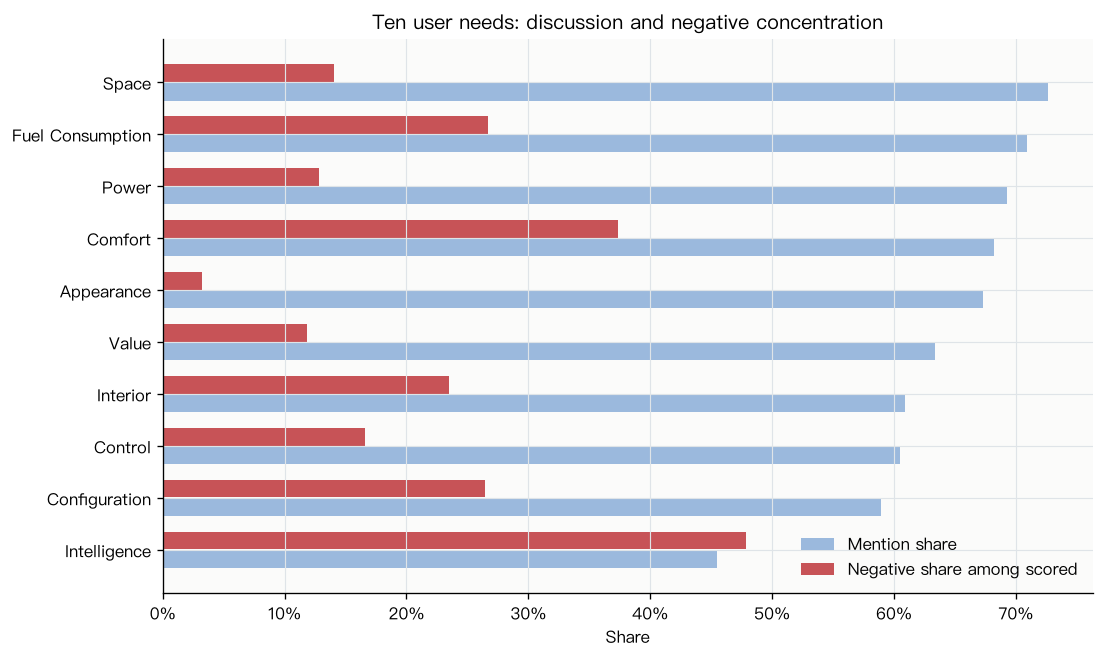

,Dimension,Mention count,Scored count,Negative count,Mention share,Negative share,Mean polarity
9,intelligence,10995,10673,5109,45.5%,47.9%,-0.058
3,comfort,16498,15260,5706,68.2%,37.4%,0.123
1,fuel_consumption,17149,16697,4456,70.9%,26.7%,0.318
8,configuration,14247,12737,3368,58.9%,26.4%,0.375
6,interior,14731,13880,3262,60.9%,23.5%,0.368
7,control,14626,13826,2297,60.5%,16.6%,0.540
0,space,17568,17077,2403,72.7%,14.1%,0.630
2,power,16740,16498,2118,69.2%,12.8%,0.650
5,value,15316,14813,1756,63.4%,11.9%,0.556
4,appearance,16275,15767,508,67.3%,3.2%,0.871


In [12]:
ordered = aspects.sort_values("mention_rate")
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(ordered))
ax.barh(y-.18, ordered.mention_rate, height=.34, color=COLORS["light"],
        label=("提及率" if ZH else "Mention share"))
ax.barh(y+.18, ordered.negative_rate_among_scored, height=.34, color=COLORS["red"],
        label=("负面率（有效评分内）" if ZH else "Negative share among scored"))
labels_y = ordered.aspect_zh if ZH else ordered.aspect.str.replace("_", " ").str.title()
ax.set_yticks(y, labels_y)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set(title=("十类用户需求：讨论热度与负面集中度" if ZH else
              "Ten user needs: discussion and negative concentration"),
       xlabel=("比例" if ZH else "Share"), ylabel="")
ax.legend(frameon=False, loc="lower right")
plt.show()

top = aspects.sort_values("negative_rate_among_scored", ascending=False).copy()
if ZH:
    top = top[["aspect_zh", "mentioned_reviews", "scored_mentions", "negative_mentions",
               "mention_rate", "negative_rate_among_scored", "mean_polarity"]]
    top.columns = ["维度", "提及评论数", "有效评分数", "负面数", "提及率", "负面率", "平均倾向"]
    display(top.style.format({"提及率": "{:.1%}", "负面率": "{:.1%}", "平均倾向": "{:.3f}"}))
else:
    top = top[["aspect", "mentioned_reviews", "scored_mentions", "negative_mentions",
               "mention_rate", "negative_rate_among_scored", "mean_polarity"]]
    top.columns = ["Dimension", "Mention count", "Scored count", "Negative count",
                   "Mention share", "Negative share", "Mean polarity"]
    display(top.style.format({"Mention share": "{:.1%}", "Negative share": "{:.1%}",
                              "Mean polarity": "{:.3f}"}))


### Dual-signal risk monitoring

The text rule first creates watchlist candidates. A candidate counts as an active alert only when it reproduces in at least 70% of 3,000 bootstrap samples and the original platform-rating decline probability is at least 80%. Every record remains a manual-review input.

In the latest complete month, 123 of 371 target series (33.2%) meet the minimum of five reviews in each of two adjacent 180-day windows. No current dual-signal alerts does not mean every series is risk-free. Bootstrap measures rule stability under resampling, not the probability of a future fault. Alert precision is not established against independent event labels.


In [13]:
latest = pd.Timestamp(monitor["latest_completed_monitoring_month"])
current = alerts[pd.to_datetime(alerts.information_cutoff_inclusive).dt.normalize().eq(latest)].copy()
if ZH:
    overview = pd.DataFrame([
        ["最近完整监测月", monitor["latest_completed_monitoring_month"]],
        ["达到样本门槛的车系", monitor["latest_eligible_series"]],
        ["当前双信号预警", monitor["latest_active_alerts"]],
        ["当前观察名单", monitor["latest_watchlist_events"]],
        ["历史预警事件", monitor["historical_alert_events"]],
    ], columns=["项目", "数值"])
else:
    overview = pd.DataFrame([
        ["Latest complete month", monitor["latest_completed_monitoring_month"]],
        ["Eligible series", monitor["latest_eligible_series"]],
        ["Current dual-signal alerts", monitor["latest_active_alerts"]],
        ["Current watchlist", monitor["latest_watchlist_events"]],
        ["Historical alert events", monitor["historical_alert_events"]],
    ], columns=["Item", "Value"])
display(overview)
display(current[["series_name", "brand", "current_reviews", "current_overall_score",
                 "score_change", "platform_rating_change", "text_rule_retrigger_probability",
                 "rating_decline_probability", "alert_status", "worst_aspect", "risk_level"]])


,Item,Value
0,Latest complete month,2026-07-31
1,Eligible series,123
2,Current dual-signal alerts,0
3,Current watchlist,1
4,Historical alert events,12


,series_name,brand,current_reviews,current_overall_score,score_change,platform_rating_change,text_rule_retrigger_probability,rating_decline_probability,alert_status,worst_aspect,risk_level
22,奥迪Q4 e-tron,奥迪,5,-0.233333,-0.15,0.06,0.316667,0.343667,watchlist,overall,medium


## 5. Data quality and temporal availability


In [14]:
if ZH:
    audit = pd.DataFrame([
        ["严格评论语料", f"{corpus['temporally_eligible_reviews']:,} 条", "完整正文、时间和来源"],
        ["排除的列表摘要", f"{corpus['autohome_list_summary_rows_excluded_from_temporal_model']} 条",
         "无详情正文，不建模"],
        ["测试起点前有评论", f"{temporal['fixed_test_series_with_any_prior_review']} 个车系",
         "固定压力测试冻结于 2026-01-01 前"],
        ["最近 180 天有评论", f"{temporal['fixed_test_series_with_recent_180d_review']} 个车系",
         "其余保留缺失标记"],
        ["复用历史标签", f"{labels['historical_labeled_reviews']:,} 条", "保留来源与标签限制"],
        ["补充标签", f"{labels['api_labeled_reviews']:,} 条", "结构校验与人工抽样"],
    ], columns=["审计项", "结果", "处理"])
else:
    audit = pd.DataFrame([
        ["Strict review corpus", f"{corpus['temporally_eligible_reviews']:,} reviews",
         "Complete text, time, and source"],
        ["Excluded list summaries", corpus["autohome_list_summary_rows_excluded_from_temporal_model"],
         "No full detail text; not modeled"],
        ["Review evidence before test origin", f"{temporal['fixed_test_series_with_any_prior_review']} series",
         "Frozen before 2026-01-01 for the fixed stress test"],
        ["Review in prior 180 days", f"{temporal['fixed_test_series_with_recent_180d_review']} series",
         "Missingness retained elsewhere"],
        ["Reused historical labels", f"{labels['historical_labeled_reviews']:,}",
         "Source and label limitations retained"],
        ["Newly supplemented labels", f"{labels['api_labeled_reviews']:,}",
         "Schema checks and manual sampling"],
    ], columns=["Audit item", "Result", "Treatment"])
display(audit)


,Audit item,Result,Treatment
0,Strict review corpus,"24,175 reviews","Complete text, time, and source"
1,Excluded list summaries,103,No full detail text; not modeled
2,Review evidence before test origin,330 series,Frozen before 2026-01-01 for the fixed stress ...
3,Review in prior 180 days,272 series,Missingness retained elsewhere
4,Reused historical labels,"16,538",Source and label limitations retained
5,Newly supplemented labels,"7,637",Schema checks and manual sampling


## 6. Dashboard and reproduction

The dashboard is a static site backed by pre-baked JSON in `app/static/data/`. All six English captures are in `assets/dashboard/en/`.

![Project overview](../assets/dashboard/en/01-overview.png)

Launch from the repository root:

    python -m http.server 8000 --directory app


## 7. Conclusions

1. Rolling one-month seasonal XGBoost is the current operational headline; sales history is the dominant signal and clearly improves on its same-scenario naive baseline.
2. The fixed six-month platform-rating model is retained as a stress test and is evaluated separately from the rolling protocol.
3. Product specifications improve the explanation of annual between-series variation; the result is an out-of-sample explanatory analysis and its WMAPE is a module-specific supporting metric.
4. Review data is primarily used for demand structure, risk monitoring, and supporting information in the stress test; mention, polarity, and sample size should be reported separately.
5. Saved predictions, split records and full-text criteria support inspection. Specification transforms are fitted within training windows; missing release dates and revisions still limit the backtest. The 2026 window has been examined during development and is not a new independent holdout.
